In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)

In [4]:
df = pd.read_csv('uci-secom.csv')

print("데이터 크기:", df.shape)
df.head()

데이터 크기: (1567, 592)


,Time,0,1,2,3,4,5,6,7,8,9,10,11,12,13,...,576,577,578,579,580,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,-0.0034,0.9455,202.4396,0.0,...,1.6765,14.9509,NaN,NaN,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,-0.0148,0.9627,200.5470,0.0,...,1.1065,10.9003,0.0096,0.0201,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,0.0013,0.9615,202.0179,0.0,...,2.0952,9.2721,0.0584,0.0484,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,-0.0033,0.9629,201.8482,0.0,...,1.7585,8.5831,0.0202,0.0149,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,-0.0072,0.9569,201.9424,0.0,...,1.6597,10.9698,NaN,NaN,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [5]:
print(df.info())

print("\n컬럼 개수:", len(df.columns))
print("\n앞쪽 컬럼:")
print(df.columns[:20].tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), object(1)
memory usage: 7.1+ MB
None

컬럼 개수: 592

앞쪽 컬럼:
['Time', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18']


In [6]:
df['Time'] = pd.to_datetime(df['Time'])

df[['Time']].head()

,Time
0,2008-07-19 11:55:00
1,2008-07-19 12:32:00
2,2008-07-19 13:17:00
3,2008-07-19 14:43:00
4,2008-07-19 15:22:00


In [7]:
sensor_cols = [
    col for col in df.columns
    if col not in ['Time', 'Pass/Fail']
]

print("센서 개수:", len(sensor_cols))
print(sensor_cols[:10])

센서 개수: 590
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [8]:
missing_ratio = df[sensor_cols].isnull().mean().sort_values(ascending=False)

missing_ratio.head(20)

157    0.911934
292    0.911934
293    0.911934
158    0.911934
492    0.855775
358    0.855775
85     0.855775
220    0.855775
246    0.649649
109    0.649649
110    0.649649
111    0.649649
518    0.649649
516    0.649649
245    0.649649
244    0.649649
382    0.649649
383    0.649649
384    0.649649
517    0.649649
dtype: float64

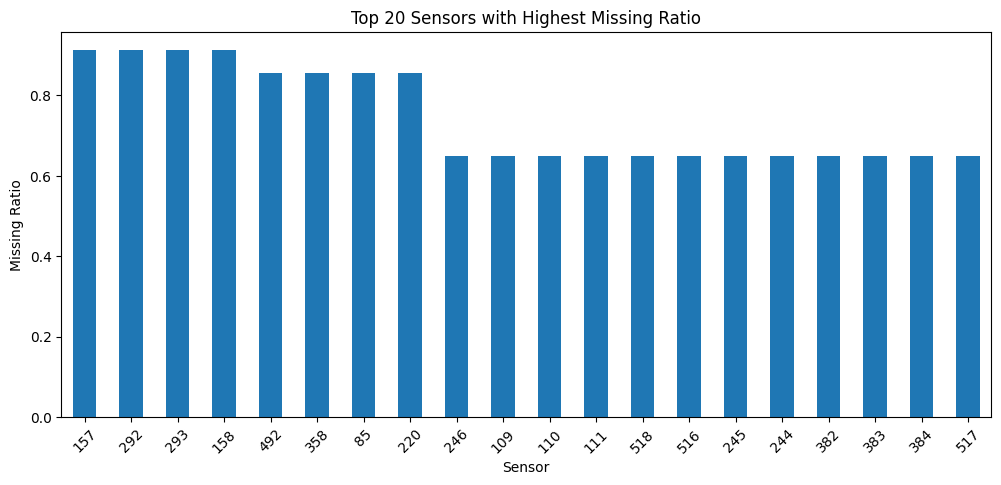

In [9]:
missing_ratio.head(20).plot(
    kind='bar',
    figsize=(12, 5)
)

plt.title('Top 20 Sensors with Highest Missing Ratio')
plt.xlabel('Sensor')
plt.ylabel('Missing Ratio')
plt.xticks(rotation=45)
plt.show()

In [10]:
high_missing_cols = missing_ratio[missing_ratio > 0.4].index

print("제거할 센서 개수:", len(high_missing_cols))

df_clean = df.drop(columns=high_missing_cols).copy()

print("제거 전:", df.shape)
print("제거 후:", df_clean.shape)

제거할 센서 개수: 32
제거 전: (1567, 592)
제거 후: (1567, 560)


In [11]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns

df_clean[numeric_cols] = df_clean[numeric_cols].fillna(
    df_clean[numeric_cols].median()
)

print("남은 결측치 수:", df_clean[numeric_cols].isnull().sum().sum())

남은 결측치 수: 0


In [12]:
df_clean[numeric_cols].describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
0,1567.0,3014.441551,73.480841,2743.2400,2966.66500,3011.49000,3056.54000,3356.3500
1,1567.0,2495.866110,80.228143,2158.7500,2452.88500,2499.40500,2538.74500,2846.4400
2,1567.0,2200.551958,29.380973,2060.6600,2181.09995,2201.06670,2218.05550,2315.2667
3,1567.0,1395.383474,439.837330,0.0000,1083.88580,1285.21440,1590.16990,3715.0417
4,1567.0,4.171281,56.103721,0.6815,1.01770,1.31680,1.51880,1114.5366
5,1567.0,100.000000,0.000000,100.0000,100.00000,100.00000,100.00000,100.0000
6,1567.0,101.116476,6.209385,82.1311,97.93780,101.51220,104.53000,129.2522
7,1567.0,0.121825,0.008936,0.0000,0.12110,0.12240,0.12380,0.1286
8,1567.0,1.462860,0.073849,1.1910,1.41125,1.46160,1.51685,1.6564
9,1567.0,-0.000842,0.015107,-0.0534,-0.01080,-0.00130,0.00840,0.0749


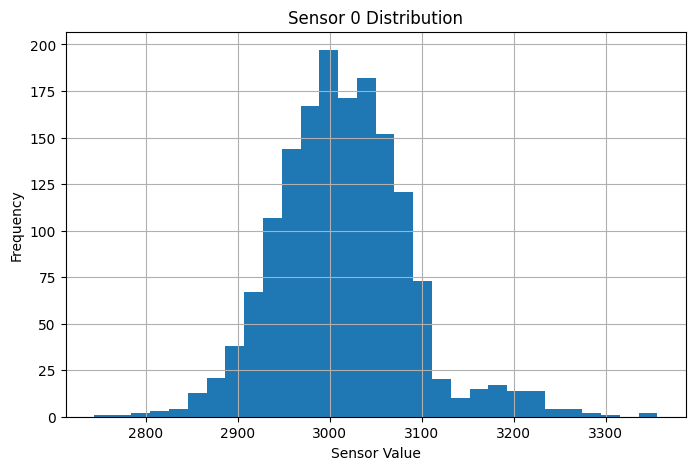

In [13]:
sensor = '0'

df_clean[sensor].hist(
    bins=30,
    figsize=(8, 5)
)

plt.title(f'Sensor {sensor} Distribution')
plt.xlabel('Sensor Value')
plt.ylabel('Frequency')
plt.show()

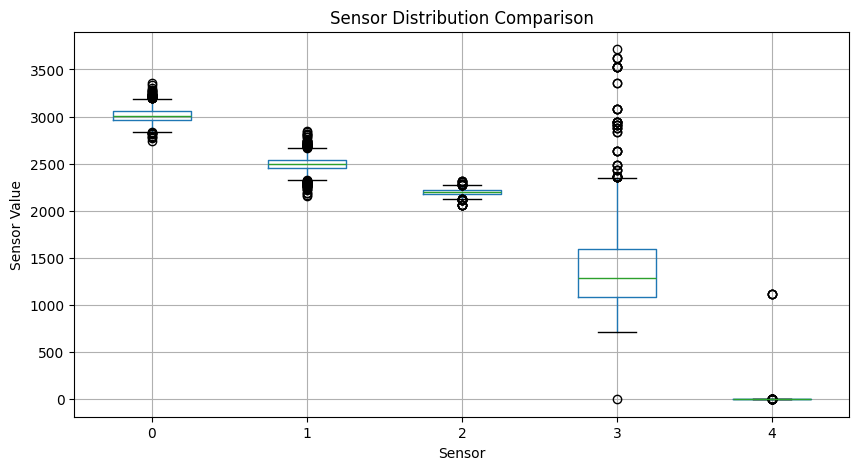

In [14]:
selected_sensors = ['0', '1', '2', '3', '4']

df_clean[selected_sensors].boxplot(
    figsize=(10, 5)
)

plt.title('Sensor Distribution Comparison')
plt.xlabel('Sensor')
plt.ylabel('Sensor Value')
plt.show()

In [15]:
selected_sensors = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

corr = df_clean[selected_sensors].corr()

corr

,0,1,2,3,4,5,6,7,8,9
0,1.000000,-0.144161,0.004667,-0.006665,-0.010819,NaN,0.002028,0.031347,-0.052735,0.009091
1,-0.144161,1.000000,0.005883,-0.008963,-0.001917,NaN,-0.025222,-0.011761,0.031244,0.024025
2,0.004667,0.005883,1.000000,0.298810,0.095881,NaN,-0.136212,-0.147116,0.023524,0.016248
3,-0.006665,-0.008963,0.298810,1.000000,-0.058351,NaN,-0.685773,0.086965,-0.102839,0.066987
4,-0.010819,-0.001917,0.095881,-0.058351,1.000000,NaN,-0.074395,-0.343413,-0.025933,0.053973
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.002028,-0.025222,-0.136212,-0.685773,-0.074395,NaN,1.000000,0.009606,0.087803,-0.049039
7,0.031347,-0.011761,-0.147116,0.086965,-0.343413,NaN,0.009606,1.000000,0.020122,-0.092130
8,-0.052735,0.031244,0.023524,-0.102839,-0.025933,NaN,0.087803,0.020122,1.000000,-0.152132
9,0.009091,0.024025,0.016248,0.066987,0.053973,NaN,-0.049039,-0.092130,-0.152132,1.000000


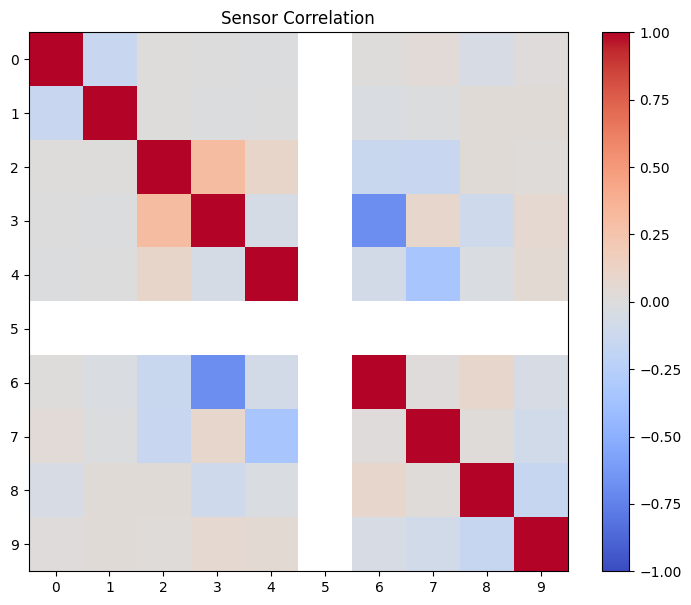

In [16]:
plt.figure(figsize=(9, 7))

plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Sensor Correlation')
plt.show()

In [17]:
outlier_ratio = {}

for col in numeric_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outliers = (
        (df_clean[col] < lower) |
        (df_clean[col] > upper)
    )
    
    outlier_ratio[col] = outliers.mean()

outlier_ratio = pd.Series(outlier_ratio).sort_values(ascending=False)

outlier_ratio.head(20)

562    0.291002
31     0.225909
40     0.210593
195    0.159541
544    0.152521
129    0.151883
312    0.149330
177    0.146777
448    0.146777
467    0.139119
545    0.130185
59     0.128271
251    0.128271
523    0.126994
23     0.124442
41     0.124442
116    0.122527
389    0.120613
335    0.116784
471    0.115507
dtype: float64

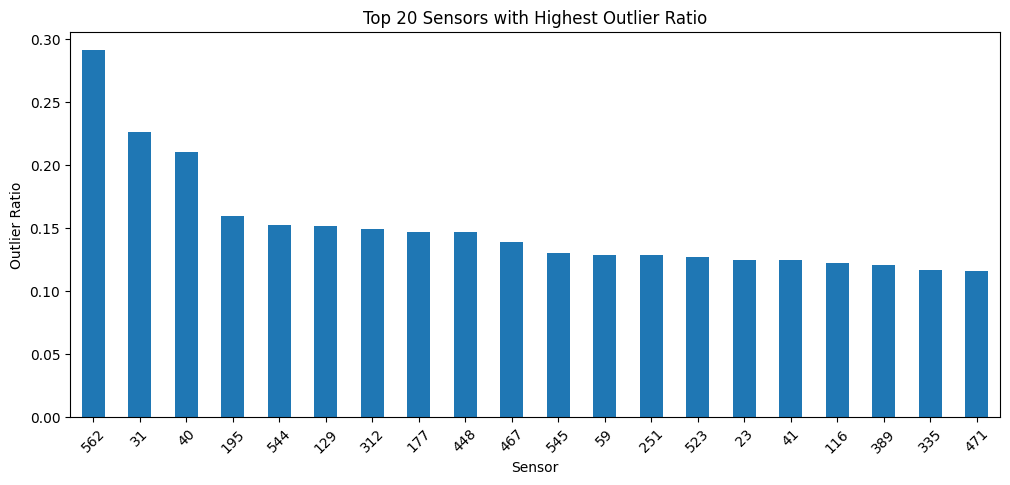

In [18]:
outlier_ratio.head(20).plot(
    kind='bar',
    figsize=(12, 5)
)

plt.title('Top 20 Sensors with Highest Outlier Ratio')
plt.xlabel('Sensor')
plt.ylabel('Outlier Ratio')
plt.xticks(rotation=45)
plt.show()

In [19]:
print('Pass/Fail' in df.columns)

True


In [20]:
df_clean['Pass/Fail'].value_counts()

Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64

In [21]:
df_clean['Pass/Fail'].value_counts(normalize=True) * 100

Pass/Fail
-1    93.363114
 1     6.636886
Name: proportion, dtype: float64

In [22]:
sensor = '0'

df_clean.groupby('Pass/Fail')[sensor].mean()

Pass/Fail
-1    3014.933137
 1    3007.526250
Name: 0, dtype: float64

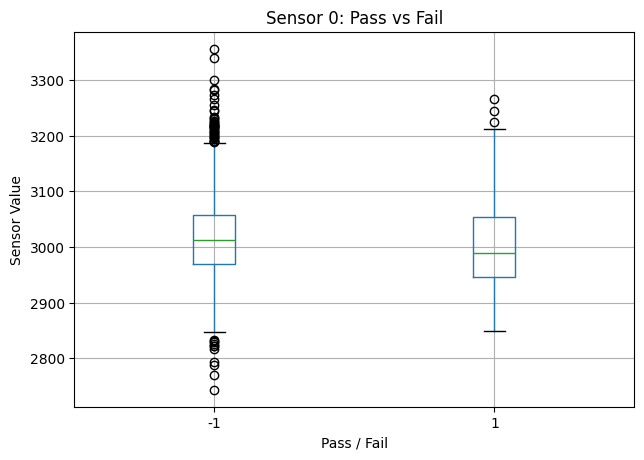

In [23]:
df_clean.boxplot(
    column=sensor,
    by='Pass/Fail',
    figsize=(7, 5)
)

plt.title(f'Sensor {sensor}: Pass vs Fail')
plt.suptitle('')
plt.xlabel('Pass / Fail')
plt.ylabel('Sensor Value')
plt.show()